In [19]:
# Cell 1: Load data, GA results, and run RF tuning for
#         Baseline + GA top-5 USING THE OLD TUNING FUNCTION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression


from sklearn.ensemble import RandomForestClassifier
import shap
# ------------------------------------
# 1) Load train / test data
# ------------------------------------
X_train = pd.read_csv("../data/X_train_xgbsel.csv")
X_test  = pd.read_csv("../data/X_test_xgbsel.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_np = y_train.to_numpy().ravel()
y_te = y_test.to_numpy().ravel()

# ------------------------------------
# 2) Load GA results (ga_best.npz)
# ------------------------------------
ga_npz = np.load("../data/20_ga_best.npz", allow_pickle=True)
print("\n[INFO] npz keys:", ga_npz.files)

top_scores = np.asarray(ga_npz["top_scores"], dtype=float)

# Build top_cols_all from npz (handle both 'top_masks' and 'top_cols')
if "top_masks" in ga_npz.files:
    raw_masks = list(ga_npz["top_masks"])  # list of boolean arrays
    top_cols_all = [
        np.flatnonzero(np.asarray(m, dtype=bool)).astype(int)
        for m in raw_masks
    ]
else:
    raw_cols = list(ga_npz["top_cols"])    # list of index arrays
    top_cols_all = [np.asarray(c, dtype=int) for c in raw_cols]

n_feat_total = X_train.shape[1]
print(f"[INFO] Loaded {len(top_cols_all)} GA feature sets.")

# ------------------------------------
# 3) Define PARAM_DIST and old tuning settings
#    (EXACTLY as in your previous test code)
# ------------------------------------
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # keep 80 if defined, same as before
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    RF hyperparameter tuning on a given feature subset using the EXACT same
    RandomizedSearchCV settings as before (so results are comparable).
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    # Clean up for direct RF instantiation
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ------------------------------------
# 4) Build feature_sets: Baseline + GA top-5 (by GA score)
# ------------------------------------
N_TOP_GA = 5

# sort GA solutions by GA score (descending)
sorted_idx = np.argsort(top_scores)[::-1]
top_idx    = sorted_idx[:N_TOP_GA]

feature_sets = []

# (0) Baseline: all 84 features
all_cols = np.arange(n_feat_total, dtype=int)
feature_sets.append({
    "name": "Baseline (ALL wrapper)",
    "cols": all_cols,
})

# (1) GA top-5 feature subsets
for rank, idx in enumerate(top_idx, 1):
    cols = np.asarray(top_cols_all[idx], dtype=int)
    feature_sets.append({
        "name": f"GA-{rank} (idx={idx})",
        "cols": cols,
        "ga_score": float(top_scores[idx]),
    })

print("\n[INFO] Feature sets to tune (Baseline + GA top-5):")
for fs in feature_sets:
    print(f"  {fs['name']}: d={len(fs['cols'])}")

# ------------------------------------
# 5) Run tuning for each feature set USING THE SAME FUNCTION
# ------------------------------------
for fs in feature_sets:
    params, cv_auc = tune_rf_for_features(fs["cols"], fs["name"])
    fs["best_params"] = params
    fs["cv_auc"]      = cv_auc


X_train: (82, 84)
X_test : (36, 84)
y_train: (82,)
y_test : (36,)

[INFO] npz keys: ['run_ids', 'top_scores', 'top_masks', 'top_cols']
[INFO] Loaded 5 GA feature sets.

[INFO] Feature sets to tune (Baseline + GA top-5):
  Baseline (ALL wrapper): d=84
  GA-1 (idx=0): d=21
  GA-2 (idx=1): d=23
  GA-3 (idx=2): d=20
  GA-4 (idx=3): d=20
  GA-5 (idx=4): d=23
[CV] Baseline (ALL wrapper) best AUC = 0.7897
[CV] Baseline (ALL wrapper) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 603}
[CV] GA-1 (idx=0) best AUC = 0.8155
[CV] GA-1 (idx=0) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 'log2', 'max_samples': 0.8, 'min_samples_leaf': 3, 'min_samples_split': 16, 'n_estimators': 217}
[CV] GA-2 (idx=1) best AUC = 0.8633
[CV] GA-2 (idx=1) best params = {'bootstrap': True, 'class_weight'

[Train CV ROC] Baseline (ALL wrapper): AUC 0.7897 ± 0.0876
[Train CV ROC] GA-1 (idx=0): AUC 0.8155 ± 0.0808
[Train CV ROC] GA-2 (idx=1): AUC 0.8633 ± 0.1015
[Train CV ROC] GA-3 (idx=2): AUC 0.8306 ± 0.1021
[Train CV ROC] GA-4 (idx=3): AUC 0.8442 ± 0.0797
[Train CV ROC] GA-5 (idx=4): AUC 0.8024 ± 0.0768


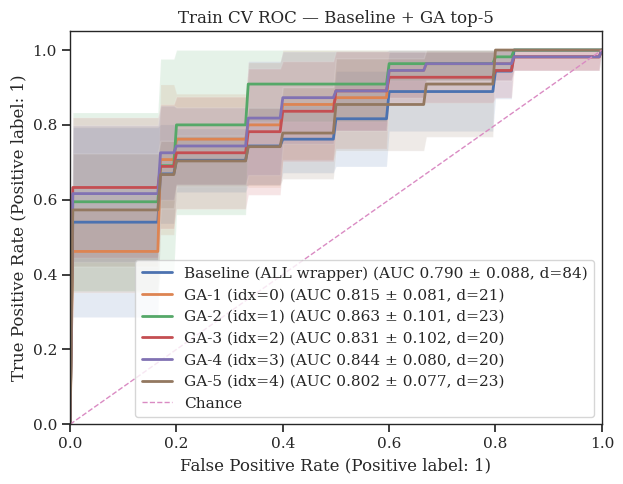

In [20]:
# Cell 2: Train CV ROC for Baseline + GA top-5
#         (NO NEW TUNING; use fs["best_params"] from Cell 1)

FPR_GRID = np.linspace(0.0, 1.0, 201)

def cv_roc_with_fixed_params(X, y, params, label, cv):
    """
    Given fixed RF params, compute mean ± std ROC curves over the given CV object.
    """
    tprs = []
    aucs = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        fpr, tpr, _ = roc_curve(y[va_idx], prob)
        auc_fold = roc_auc_score(y[va_idx], prob)
        aucs.append(auc_fold)

        tpr_i = np.interp(FPR_GRID, fpr, tpr, left=0.0, right=1.0)
        tpr_i[0]  = 0.0
        tpr_i[-1] = 1.0
        tprs.append(tpr_i)

    tprs     = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    auc_mean = float(np.mean(aucs))
    auc_std  = float(np.std(aucs))

    print(f"[Train CV ROC] {label}: AUC {auc_mean:.4f} ± {auc_std:.4f}")
    return mean_tpr, std_tpr, auc_mean, auc_std

plt.figure(figsize=(6.4, 5.0))

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    X_sub = X_train.iloc[:, cols].to_numpy()

    mean_tpr, std_tpr, auc_mean, auc_std = cv_roc_with_fixed_params(
        X_sub, y_np, params, fs["name"], cv5
    )

    fs["cv_auc_mean"] = auc_mean
    fs["cv_auc_std"]  = auc_std

    label = f"{fs['name']} (AUC {auc_mean:.3f} ± {auc_std:.3f}, d={len(cols)})"
    plt.plot(FPR_GRID, mean_tpr, lw=2, label=label)
    plt.fill_between(
        FPR_GRID,
        np.maximum(mean_tpr - std_tpr, 0.0),
        np.minimum(mean_tpr + std_tpr, 1.0),
        alpha=0.15,
    )

plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Train CV ROC — Baseline + GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [21]:
# ------------------------------------------------
# 1) Collect only GA-based feature sets (exclude Baseline)
# ------------------------------------------------
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]

if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found. Make sure feature_sets contains entries named 'GA-1', 'GA-2', ...")

# Each GA subset already has:
#   - fs["cv_auc_mean"]: mean AUC over CV folds (from Cell 2)
#   - fs["cv_auc_std"] : std  AUC over CV folds (from Cell 2)
# We now summarize:
#   (1) per-subset CV AUC statistics in a table
#   (2) across-subset AUC stability: how much these per-subset means vary
#       -> treat each GA run's cv_auc_mean as one observation
#          and compute mean / std across runs.

subset_names = [fs["name"] for fs in ga_feature_sets]
subset_sizes = [len(fs["cols"]) for fs in ga_feature_sets]
ga_auc_means = np.array([fs["cv_auc_mean"] for fs in ga_feature_sets], dtype=float)
ga_auc_stds  = np.array([fs["cv_auc_std"]  for fs in ga_feature_sets], dtype=float)

# --------------------------------------------
# Table 1: per-GA-subset CV AUC summary
# --------------------------------------------
auc_table = pd.DataFrame({
    "subset": subset_names,
    "n_features": subset_sizes,
    "cv_auc_mean_over_folds": ga_auc_means,
    "cv_auc_std_over_folds": ga_auc_stds,
})
auc_table = auc_table.sort_values("subset").reset_index(drop=True)

# Across-subset AUC stability:
#   - ga_auc_means: length = n_GA_runs (e.g., 5)
#   - mean: average AUC across GA runs
#   - std : how much the *average* AUC changes between GA runs
auc_across_mean = float(ga_auc_means.mean())
auc_across_std  = float(ga_auc_means.std(ddof=1))  # sample std across GA subsets

auc_stability_summary = pd.DataFrame({
    "metric": ["across_subsets_mean_AUC", "across_subsets_std_AUC"],
    "value":  [auc_across_mean,            auc_across_std]
})

# --------------------------------------------
# 2) Jaccard similarity between GA subsets
# --------------------------------------------
def jaccard_similarity(indices_a, indices_b):
    """
    Compute Jaccard similarity between two index sets:
      J(A,B) = |A ∩ B| / |A ∪ B|
    """
    set_a = set(indices_a)
    set_b = set(indices_b)
    union = set_a | set_b
    if not union:
        return 0.0
    inter = set_a & set_b
    return len(inter) / len(union)

n_ga   = len(ga_feature_sets)
labels = [fs["name"] for fs in ga_feature_sets]

jacc_matrix = np.zeros((n_ga, n_ga), dtype=float)

# Full Jaccard matrix (symmetric, diagonal = 1)
for i in range(n_ga):
    for j in range(n_ga):
        jacc_matrix[i, j] = jaccard_similarity(
            ga_feature_sets[i]["cols"],
            ga_feature_sets[j]["cols"]
        )

# DataFrame for a clean matrix view
jacc_df = pd.DataFrame(jacc_matrix, index=labels, columns=labels)

# Upper-triangular values (i < j) for summary mean ± std
upper_vals = [
    jacc_matrix[i, j]
    for i in range(n_ga)
    for j in range(i + 1, n_ga)
]

jacc_mean = float(np.mean(upper_vals)) if upper_vals else 0.0
jacc_std  = float(np.std(upper_vals, ddof=1)) if len(upper_vals) > 1 else 0.0

jacc_summary = pd.DataFrame({
    "metric": ["mean_Jaccard_over_pairs", "std_Jaccard_over_pairs"],
    "value":  [jacc_mean,                  jacc_std]
})


# --------------------------------------------
# 3) Sensitivity comparison: mean recall at 0.5
# --------------------------------------------
def cv_sensitivity_at_threshold(X, y, params, cv, threshold=0.5):
    """
    Compute mean ± std sensitivity (recall for positive class)
    across CV folds, at a fixed probability threshold.
    """
    recalls = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        y_pred = (prob >= threshold).astype(int)
        rec = recall_score(y[va_idx], y_pred, pos_label=1)
        recalls.append(rec)

    recalls = np.array(recalls, dtype=float)
    return float(recalls.mean()), float(recalls.std(ddof=1))

sens_rows = []
for fs in ga_feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])
    X_sub  = X_train.iloc[:, cols].to_numpy()
    y_sub  = y_np  # same labels as before

    sens_mean, sens_std = cv_sensitivity_at_threshold(
        X_sub, y_sub, params, cv5, threshold=0.5
    )

    sens_rows.append({
        "subset": fs["name"],
        "n_features": len(cols),
        "cv_auc_mean_over_folds": fs["cv_auc_mean"],
        "cv_auc_std_over_folds":  fs["cv_auc_std"],
        "sensitivity_mean_at_0.5": sens_mean,
        "sensitivity_std_at_0.5":  sens_std,
    })

sens_table = pd.DataFrame(sens_rows).sort_values("subset").reset_index(drop=True)


# --------------------------------------------
# 4) Display all tables nicely
# --------------------------------------------
# (You can remove .round(...) if you want full precision.)
display(auc_table.round(3))             # Table: per-GA-subset AUC
display(auc_stability_summary.round(4)) # Table: across-subset AUC stability
display(jacc_df.round(3))               # Table: Jaccard matrix
display(jacc_summary.round(4))          # Table: Jaccard mean/std
display(sens_table.round(3))            # Table: AUC + sensitivity per GA subset


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds
0,GA-1 (idx=0),21,0.815,0.081
1,GA-2 (idx=1),23,0.863,0.101
2,GA-3 (idx=2),20,0.831,0.102
3,GA-4 (idx=3),20,0.844,0.080
4,GA-5 (idx=4),23,0.802,0.077


,metric,value
0,across_subsets_mean_AUC,0.8312
1,across_subsets_std_AUC,0.0239


,GA-1 (idx=0),GA-2 (idx=1),GA-3 (idx=2),GA-4 (idx=3),GA-5 (idx=4)
GA-1 (idx=0),1.000,0.128,0.206,0.139,0.222
GA-2 (idx=1),0.128,1.000,0.229,0.229,0.150
GA-3 (idx=2),0.206,0.229,1.000,0.143,0.194
GA-4 (idx=3),0.139,0.229,0.143,1.000,0.162
GA-5 (idx=4),0.222,0.150,0.194,0.162,1.000


,metric,value
0,mean_Jaccard_over_pairs,0.1802
1,std_Jaccard_over_pairs,0.0399


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds,sensitivity_mean_at_0.5,sensitivity_std_at_0.5
0,GA-1 (idx=0),21,0.815,0.081,0.964,0.081
1,GA-2 (idx=1),23,0.863,0.101,0.945,0.050
2,GA-3 (idx=2),20,0.831,0.102,0.927,0.076
3,GA-4 (idx=3),20,0.844,0.080,0.871,0.137
4,GA-5 (idx=4),23,0.802,0.077,0.909,0.111


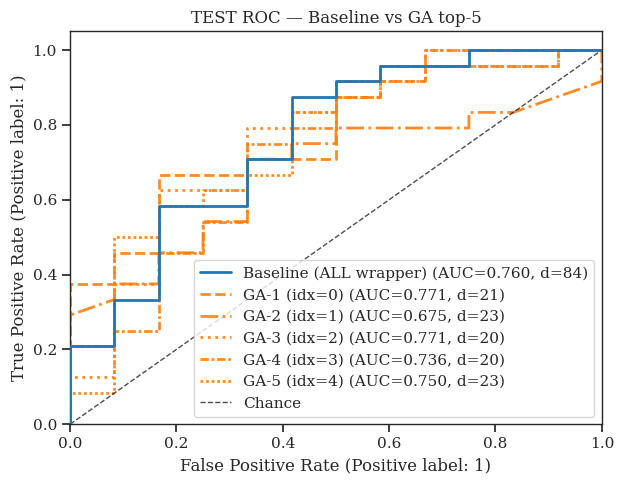


===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====
                     name  n_features  cv_auc_best  cv_auc_mean  cv_auc_std  \
0  Baseline (ALL wrapper)          84     0.789697     0.789697    0.087609   
1            GA-1 (idx=0)          21     0.815455     0.815455    0.080838   
2            GA-2 (idx=1)          23     0.863333     0.863333    0.101479   
3            GA-3 (idx=2)          20     0.830606     0.830606    0.102110   
4            GA-4 (idx=3)          20     0.844242     0.844242    0.079729   
5            GA-5 (idx=4)          23     0.802424     0.802424    0.076838   

   test_auc  
0  0.760417  
1  0.770833  
2  0.675347  
3  0.770833  
4  0.736111  
5  0.750000  


In [22]:
# Cell 3: Final train on FULL TRAIN + TEST ROC (Baseline + GA top-5)

plt.figure(figsize=(6.4, 5.0))

test_rows = []

# Colors: one for Baseline, one shared color for all GA subsets
COLOR_BASELINE = "tab:blue"   # unique color for Baseline
COLOR_GA       = "tab:orange" # shared color for all GA feature sets

# Different linestyles for GA-1 ... GA-5 (same color, different pattern)
GA_LINESTYLES = [
    "--",              # GA-1
    "-.",              # GA-2
    ":",               # GA-3
    (0, (3, 1, 1, 1)), # GA-4 (custom dash pattern)
    (0, (1, 1)),       # GA-5 (dense dash)
]

ga_idx = 0  # index to assign linestyles for GA subsets

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # Style for Baseline vs GA subsets
    if fs["name"].lower().startswith("baseline"):
        # Baseline: thick, solid, fully opaque, highest z-order
        curve_color = COLOR_BASELINE
        line_style  = "-"
        alpha       = 1.0
        z           = 3
    else:
        # GA subsets: same color, different linestyles, slightly thinner
        curve_color = COLOR_GA
        # Safeguard: if more GA sets than styles, wrap around
        line_style  = GA_LINESTYLES[min(ga_idx, len(GA_LINESTYLES) - 1)]
        alpha       = 0.9
        z           = 2
        ga_idx += 1

    label = f"{fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),  # from tuning
        "test_auc":    float(auc_te),
    })

# Chance line
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance", color="black", alpha=0.7)

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Baseline vs GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(test_rows)
print("\n===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====")
print(results_df[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]])


In [23]:
# 0) GA-only feature sets (exclude Baseline)
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found in feature_sets (expected names starting with 'GA-').")

# 1) Lookup tables from auc_table / sens_table
#    - auc_table columns: "subset", "cv_auc_mean_over_folds", "cv_auc_std_over_folds"
#    - sens_table columns: "subset", "sensitivity_mean_at_0.5", "sensitivity_std_at_0.5"
auc_lookup  = {row["subset"]: row for _, row in auc_table.iterrows()}
sens_lookup = {row["subset"]: row for _, row in sens_table.iterrows()}

# 2) Attach CV AUC / sensitivity stats into each GA feature set dict
for fs in ga_feature_sets:
    name = fs["name"]

    # ---- CV AUC mean / std (from nested CV table) ----
    auc_row = auc_lookup.get(name, None)
    if auc_row is not None:
        fs["cv_auc_mean"] = float(auc_row["cv_auc_mean_over_folds"])
        fs["cv_auc_std"]  = float(auc_row["cv_auc_std_over_folds"])
    else:
        fs["cv_auc_mean"] = float("nan")
        fs["cv_auc_std"]  = float("nan")

    # ---- Sensitivity mean / std at threshold 0.5 ----
    sens_row = sens_lookup.get(name, None)
    if sens_row is not None:
        fs["sensitivity_mean_at_0.5"] = float(sens_row["sensitivity_mean_at_0.5"])
        fs["sensitivity_std_at_0.5"]  = float(sens_row["sensitivity_std_at_0.5"])
    else:
        fs["sensitivity_mean_at_0.5"] = float("nan")
        fs["sensitivity_std_at_0.5"]  = float("nan")

# 3) Filter candidates by sensitivity >= 0.8
SENS_MIN = 0.80
eligible = [
    fs for fs in ga_feature_sets
    if np.isfinite(fs.get("sensitivity_mean_at_0.5", np.nan))
    and fs["sensitivity_mean_at_0.5"] >= SENS_MIN
    and np.isfinite(fs.get("cv_auc_mean", np.nan))
]

if len(eligible) == 0:
    raise ValueError(f"No GA subsets meet sensitivity >= {SENS_MIN:.2f}. Consider lowering SENS_MIN or checking sens_table.")

# 4) Choose the subset whose CV train AUC is closest to the median among eligible candidates
eligible_cv_means = np.array([fs["cv_auc_mean"] for fs in eligible], dtype=float)
target_median = float(np.median(eligible_cv_means))

# Primary key: abs distance to median
# Tiebreakers: lower AUC std, then fewer features (optional but reasonable)
best_ga = min(
    eligible,
    key=lambda fs: (
        abs(fs["cv_auc_mean"] - target_median),
        fs.get("cv_auc_std", np.inf),
        len(fs["cols"]),
    )
)

# 5) Print summary
print("[INFO] Eligible GA candidates (sensitivity >= {:.2f}):".format(SENS_MIN))
for fs in sorted(eligible, key=lambda x: x["cv_auc_mean"]):
    print(
        f"  {fs['name']}: d={len(fs['cols']):2d}, "
        f"CV AUC={fs['cv_auc_mean']:.4f} ± {fs.get('cv_auc_std', float('nan')):.4f}, "
        f"sens@0.5={fs['sensitivity_mean_at_0.5']:.4f}"
    )

print("\n[INFO] Median CV AUC among eligible:", target_median)
print("[INFO] Chosen for SHAP (closest to median CV AUC):")
print(" name      :", best_ga["name"])
print(" n_features:", len(best_ga["cols"]))
print(" CV AUC    :", best_ga["cv_auc_mean"], "±", best_ga.get("cv_auc_std", float("nan")))
print(" sens@0.5  :", best_ga.get("sensitivity_mean_at_0.5", float("nan")))

[INFO] Eligible GA candidates (sensitivity >= 0.80):
  GA-5 (idx=4): d=23, CV AUC=0.8024 ± 0.0768, sens@0.5=0.9091
  GA-1 (idx=0): d=21, CV AUC=0.8155 ± 0.0808, sens@0.5=0.9636
  GA-3 (idx=2): d=20, CV AUC=0.8306 ± 0.1021, sens@0.5=0.9273
  GA-4 (idx=3): d=20, CV AUC=0.8442 ± 0.0797, sens@0.5=0.8709
  GA-2 (idx=1): d=23, CV AUC=0.8633 ± 0.1015, sens@0.5=0.9455

[INFO] Median CV AUC among eligible: 0.8306060606060607
[INFO] Chosen for SHAP (closest to median CV AUC):
 name      : GA-3 (idx=2)
 n_features: 20
 CV AUC    : 0.8306060606060607 ± 0.10210997150617436
 sens@0.5  : 0.9272727272727274


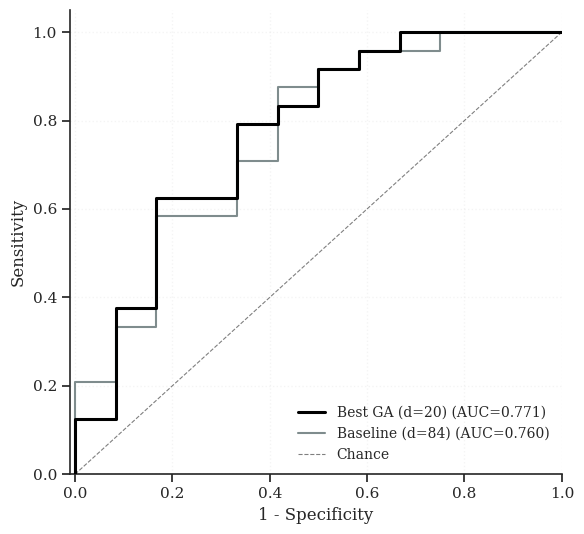

✅ Success: Academic ROC plot (d=20 vs d=84) saved to 'rf_xgboost_20\Final_ROC_Comparison_d20_Unified.png'


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------
# 1. Directory & Academic Style Setup
# ---------------------------------------------------------
save_folder = "rf_xgboost_20"
os.makedirs(save_folder, exist_ok=True)

# Set academic plotting style (Serif font for journals)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.2
plt.figure(figsize=(6, 5.5))

# ---------------------------------------------------------
# 2. Model Evaluation (GA d=20 vs. Baseline d=84)
# ---------------------------------------------------------
# Identify baseline from the feature_sets list
baseline_fs = next(fs for fs in feature_sets if fs["name"].lower().startswith("baseline"))

# Unified Labels with Dimensionality (d)
plot_sets = [
    {"data": best_ga, "label_name": "Best GA (d=20)"},
    {"data": baseline_fs, "label_name": "Baseline (d=84)"}
]

for item in plot_sets:
    fs = item["data"]
    display_name = item["label_name"]
    
    cols = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    # Prepare data subsets
    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:, cols].to_numpy()

    # Fit RF Classifier
    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    # Calculate AUC and ROC coordinates
    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # Styling: Strong black for GA, Muted gray for Baseline
    if "GA" in display_name:
        color, lw, z = "#000000", 2.2, 3
    else:
        color, lw, z = "#7f8c8d", 1.5, 1

    plt.plot(fpr, tpr, lw=lw, label=f"{display_name} (AUC={auc_te:.3f})", color=color, zorder=z)

# ---------------------------------------------------------
# 3. Plot Aesthetics (Unified Labels: Sensitivity & Specificity)
# ---------------------------------------------------------
# Reference line for random performance
plt.plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', alpha=0.5, label="Chance")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])

# Unified axis names for medical/technical journals
plt.xlabel("1 - Specificity", fontsize=12) 
plt.ylabel("Sensitivity", fontsize=12)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(alpha=0.2, ls=':')
sns.despine() # Remove top and right borders
plt.tight_layout()

# ---------------------------------------------------------
# 4. Save to Folder
# ---------------------------------------------------------
save_path = os.path.join(save_folder, "Final_ROC_Comparison_d20_Unified.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Success: Academic ROC plot (d=20 vs d=84) saved to '{save_path}'")

[GA-Best] AUC: 0.7708 (95% CI: 0.5720 - 0.9286) | Features: 20
[Baseline] AUC: 0.7604 (95% CI: 0.5720 - 0.9231) | Features: 84
✅ Success: Plot saved to 'rf_xgboost_20\rf_xgboost_selected_20_bootstrap_auc.png'


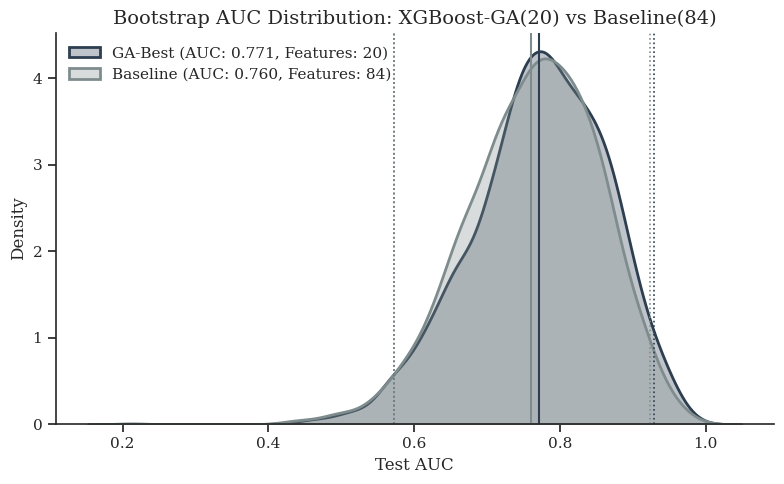

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import os

# ---------------------------------------------------------
# 1. Model Training & Prediction
# ---------------------------------------------------------

# GA-Best Model: 20 features (Pre-selected by XGBoost then optimized by GA)
cols_ga = np.asarray(best_ga["cols"], dtype=int)
params_ga = dict(best_ga["best_params"])
Xtr_ga = X_train.iloc[:, cols_ga].to_numpy()
Xte_ga = X_test.iloc[:, cols_ga].to_numpy()

clf_ga = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params_ga)
clf_ga.fit(Xtr_ga, y_np)
prob_ga = clf_ga.predict_proba(Xte_ga)[:, 1]

# Baseline Model: 84 features (Using all available columns)
Xtr_bl = X_train.to_numpy()
Xte_bl = X_test.to_numpy()
params_bl = dict(baseline_fs["best_params"]) 

clf_bl = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params_bl)
clf_bl.fit(Xtr_bl, y_np)
prob_bl = clf_bl.predict_proba(Xte_bl)[:, 1]

# ---------------------------------------------------------
# 2. Bootstrap Function Definition
# ---------------------------------------------------------
def get_bootstrap_auc(y_true, y_prob, n_bootstrap=2000):
    """Generates a distribution of AUC scores using bootstrap resampling."""
    rng = np.random.default_rng(2026)
    boot_stats = []
    n = len(y_true)
    
    for _ in range(n_bootstrap):
        # Resample indices with replacement
        idx = rng.integers(0, n, size=n)
        y_b, s_b = y_true[idx], y_prob[idx]
        
        # Skip if the bootstrap sample contains only one class
        if len(np.unique(y_b)) < 2: 
            continue
            
        boot_stats.append(roc_auc_score(y_b, s_b))
    return np.array(boot_stats)

# ---------------------------------------------------------
# 3. Bootstrap Execution & Data Structuring
# ---------------------------------------------------------
y_true_arr = np.asarray(y_te)
boot_ga = get_bootstrap_auc(y_true_arr, prob_ga)
boot_bl = get_bootstrap_auc(y_true_arr, prob_bl)

# Dictionary to store results for future use
rf_xgboost_20 = {}

for name, boot, prob in [("GA-Best", boot_ga, prob_ga), ("Baseline", boot_bl, prob_bl)]:
    lo, hi = np.percentile(boot, [2.5, 97.5]) # 95% Confidence Interval
    observed = roc_auc_score(y_true_arr, prob)
    
    rf_xgboost_20[name] = {
        "auc_observed": observed,
        "ci_lower": lo,
        "ci_upper": hi,
        "boot_samples": boot,
        "feature_count": 20 if name == "GA-Best" else 84
    }
    print(f"[{name}] AUC: {observed:.4f} (95% CI: {lo:.4f} - {hi:.4f}) | Features: {rf_xgboost_20[name]['feature_count']}")

# ---------------------------------------------------------
# 4. Visualization & Folder/File Saving
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
colors = {"GA-Best": "#2c3e50", "Baseline": "#7f8c8d"}

for name, data in rf_xgboost_20.items():
    # Plot Kernel Density Estimate (KDE)
    sns.kdeplot(data["boot_samples"], 
                label=f"{name} (AUC: {data['auc_observed']:.3f}, Features: {data['feature_count']})", 
                color=colors[name], fill=True, alpha=0.3, lw=2)
    
    # Add vertical lines for observed AUC (solid) and 95% CI (dotted)
    plt.axvline(data['auc_observed'], color=colors[name], ls='-', lw=1.5)
    plt.axvline(data['ci_lower'], color=colors[name], ls=':', lw=1.2)
    plt.axvline(data['ci_upper'], color=colors[name], ls=':', lw=1.2)

plt.title("Bootstrap AUC Distribution: XGBoost-GA(20) vs Baseline(84)", fontsize=14)
plt.xlabel("Test AUC", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(frameon=False, loc='upper left')
sns.despine()
plt.tight_layout()

# --- Directory and File Management ---
save_folder = "rf_xgboost_20"
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

# Define path for the PNG file
save_path = os.path.join(save_folder, "rf_xgboost_selected_20_bootstrap_auc.png")

# Save high-resolution image
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"✅ Success: Plot saved to '{save_path}'")
plt.show()

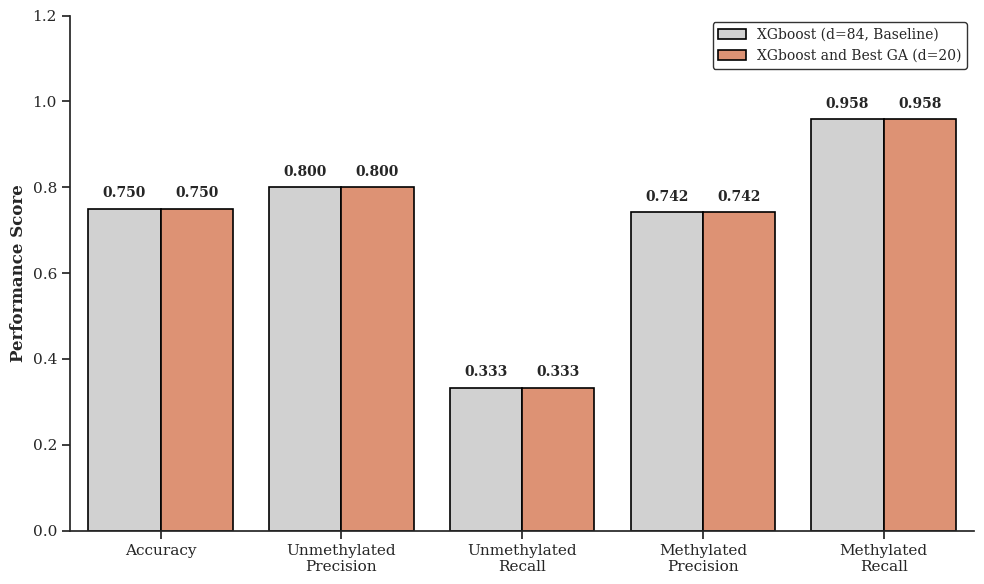

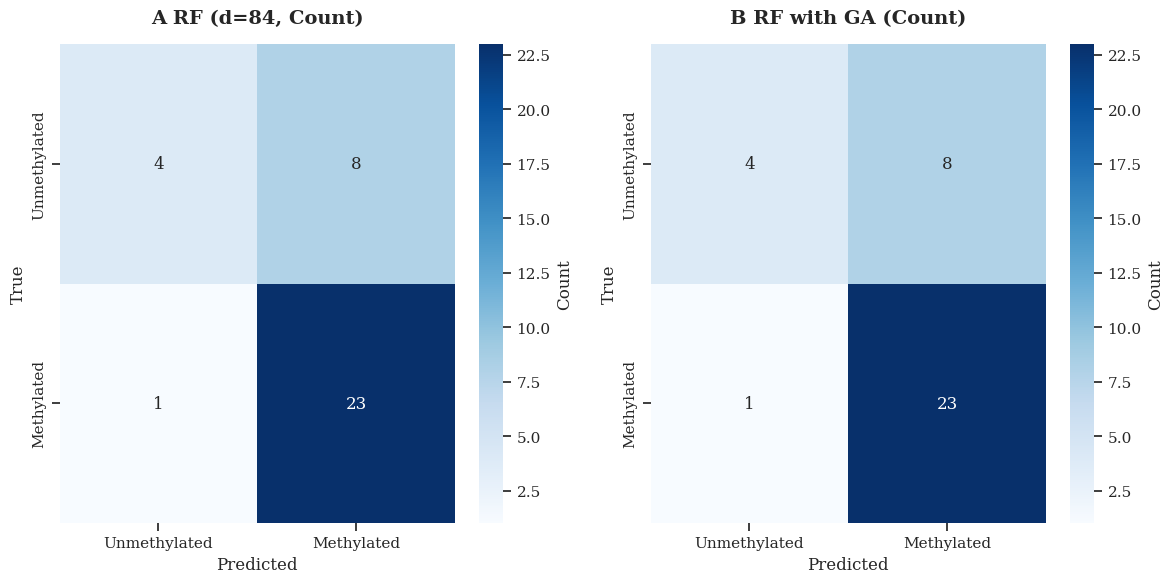

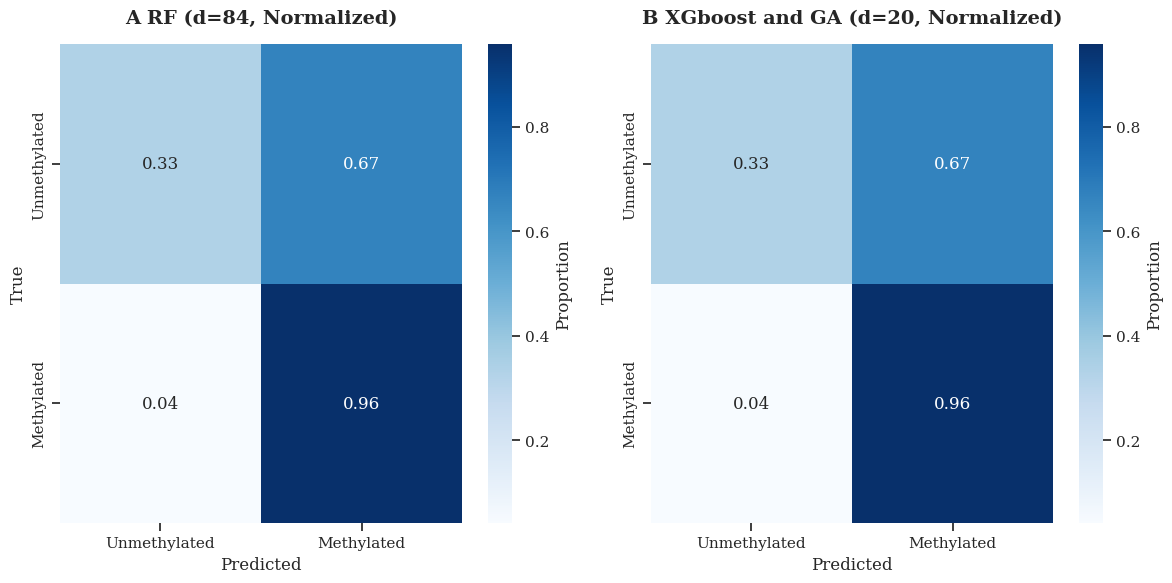

In [26]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. 초기 설정: 폴더 및 논문용 스타일 (Serif 폰트)
# ---------------------------------------------------------
folder_path = "rf_xgboost_20"
os.makedirs(folder_path, exist_ok=True)
sns.set_theme(style="ticks", rc={"font.family": "serif"})
class_labels = ['Unmethylated', 'Methylated']

# ---------------------------------------------------------
# 2. 모델 예측값 생성 (변수가 정의되지 않았을 경우를 대비)
# ---------------------------------------------------------

# A: Baseline 모델 (모든 피처 사용)
Xtr_all = X_train.to_numpy()
Xte_all = X_test.to_numpy()
clf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **baseline_fs["best_params"])
clf_base.fit(Xtr_all, y_np)
y_pred_baseline = clf_base.predict(Xte_all)

# B: Best GA 모델 (선택된 d개 피처 사용)
cols_ga = np.asarray(best_ga["cols"], dtype=int)
Xtr_ga = X_train.iloc[:, cols_ga].to_numpy()
Xte_ga = X_test.iloc[:, cols_ga].to_numpy()
clf_ga = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_ga["best_params"])
clf_ga.fit(Xtr_ga, y_np)
y_pred_ga = clf_ga.predict(Xte_ga)

# ---------------------------------------------------------
# 3. 성능 지표 바 차트 생성 및 저장 (RF_Metrics.png)
# ---------------------------------------------------------
metrics_data = {
    'Metric': ['Accuracy', 'Unmethylated\nPrecision', 'Unmethylated\nRecall', 
               'Methylated\nPrecision', 'Methylated\nRecall'] * 2,
    'Score': [
        # RF Baseline
        accuracy_score(y_test, y_pred_baseline), 
        precision_score(y_test, y_pred_baseline, average=None)[0],
        recall_score(y_test, y_pred_baseline, average=None)[0],
        precision_score(y_test, y_pred_baseline, average=None)[1],
        recall_score(y_test, y_pred_baseline, average=None)[1],
        # RF Best GA
        accuracy_score(y_test, y_pred_ga), 
        precision_score(y_test, y_pred_ga, average=None)[0],
        recall_score(y_test, y_pred_ga, average=None)[0],
        precision_score(y_test, y_pred_ga, average=None)[1],
        recall_score(y_test, y_pred_ga, average=None)[1]
    ],
    'Model': ['XGboost (d=84, Baseline)'] * 5 + [f'XGboost and Best GA (d={len(cols_ga)})'] * 5
}
df_metrics = pd.DataFrame(metrics_data)

fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', 
            palette=['#d1d1d1', '#ef8a62'], edgecolor='black', linewidth=1.2) # GA 강조색 변경

ax_bar.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax_bar.set_xlabel('')
ax_bar.set_ylim(0, 1.2)
sns.despine()

for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt='%.3f', padding=6, weight='bold', size=10)

plt.legend(frameon=True, loc='upper right', fontsize=10, edgecolor='black')
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "RF_Metrics.png"), dpi=300)
plt.show()

# ---------------------------------------------------------
# 4. Confusion Matrix 생성 및 저장
# ---------------------------------------------------------
cm_base = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1])
cm_ga = confusion_matrix(y_test, y_pred_ga, labels=[0, 1])

# 정규화
cm_base_norm = cm_base.astype('float') / cm_base.sum(axis=1)[:, np.newaxis]
cm_ga_norm = cm_ga.astype('float') / cm_ga.sum(axis=1)[:, np.newaxis]

# --- A: Count 버전 저장 ---
fig_cnt, axes_cnt = plt.subplots(1, 2, figsize=(12, 6))
for i, (cm, title) in enumerate(zip([cm_base, cm_ga], ["A RF (d=84, Count)", "B RF with GA (Count)"])):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
                yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_cnt[i])
    axes_cnt[i].set_title(title, fontsize=14, fontweight='bold', pad=15)
    axes_cnt[i].set_xlabel("Predicted")
    axes_cnt[i].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "BestGa_confusion_matrices_RF_count.png"), dpi=300)

# --- B: Normalized 버전 저장 ---
fig_norm, axes_norm = plt.subplots(1, 2, figsize=(12, 6))
titles_norm = [f"A RF (d={X_train.shape[1]}, Normalized)", f"B XGboost and GA (d={len(cols_ga)}, Normalized)"]

for i, (cm, title) in enumerate(zip([cm_base_norm, cm_ga_norm], titles_norm)):
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
                yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[i])
    axes_norm[i].set_title(title, fontsize=14, fontweight='bold', pad=15)
    axes_norm[i].set_xlabel("Predicted")
    axes_norm[i].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "BestGa_confusion_matrices_RF_normalized.png"), dpi=300)
plt.show()

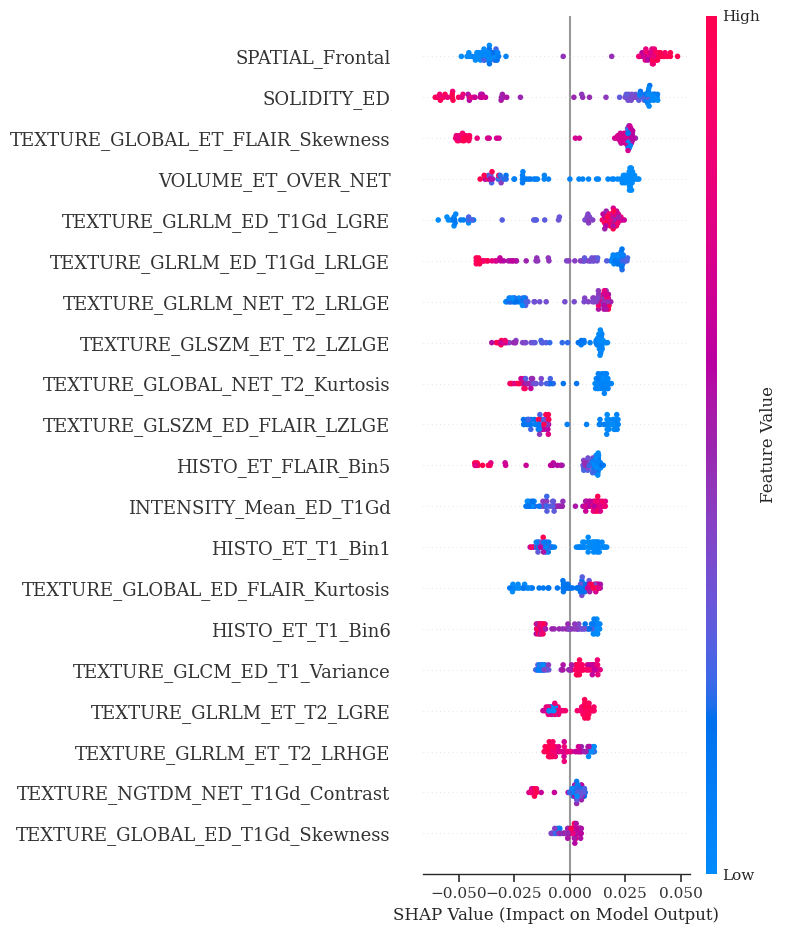

[INFO] SHAP Summary Plot saved to: rf_xgboost_20\Figure_SHAP_Summary.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
import os

# ---------------------------------------------------------
# 1. Setup and Directory Management
# ---------------------------------------------------------
RANDOM_STATE = 42
save_folder = "rf_xgboost_20"


# 논문용 폰트 설정
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 2. 모델 학습 (Best GA Subset)
# ---------------------------------------------------------
ga_cols   = np.asarray(best_ga["cols"], dtype=int)
ga_params = dict(best_ga["best_params"])

Xtr_ga = X_train.iloc[:, ga_cols]
y_tr   = y_train.to_numpy().ravel()

rf_ga_shap = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **ga_params
)
rf_ga_shap.fit(Xtr_ga, y_tr)

# ---------------------------------------------------------
# 3. SHAP 계산
# ---------------------------------------------------------
explainer = shap.TreeExplainer(rf_ga_shap)
shap_values = explainer.shap_values(Xtr_ga)

# RandomForest의 경우 클래스 0, 1에 대한 값이 리스트로 반환될 수 있음
# 이진 분류에서 Positive(1) 클래스에 대한 영향력 선택
if isinstance(shap_values, list):
    # scikit-learn RF는 보통 [samples, features, classes] 혹은 list of [samples, features]
    vals_to_plot = shap_values[1]
else:
    # 3차원 배열인 경우 [samples, features, class_index]
    vals_to_plot = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

# ---------------------------------------------------------
# 4. 시각화 및 저장
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# SHAP Summary Plot 생성
# show=False로 설정해야 저장이 가능합니다.
shap.summary_plot(
    vals_to_plot, 
    Xtr_ga, 
    feature_names=Xtr_ga.columns,
    plot_type="dot", 
    show=False
)

# 논문 스타일을 위한 미세 조정
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.gcf().axes[-1].set_ylabel("Feature Value", fontsize=12) # Colorbar label

# 여백 조정 및 저장
plt.tight_layout()
save_path = os.path.join(save_folder, "Figure_SHAP_Summary.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] SHAP Summary Plot saved to: {save_path}")

In [28]:
# --- SHAP importance = mean(|SHAP|) over samples ---
mean_abs_shap = np.abs(vals).mean(axis=0)  # (n_features,)

imp = pd.Series(mean_abs_shap, index=Xtr_ga.columns).sort_values(ascending=False)

top_k = 20
top_imp = imp.head(top_k)

print("\n[INFO] Top features by mean(|SHAP|):")
for i, (fname, score) in enumerate(top_imp.items(), 1):
    print(f"{i:02d}. {fname}  (mean|SHAP|={score:.6f})")

top_features = top_imp.index.tolist()
print("\n[INFO] Top feature names only:")
print(top_features)


[INFO] Top features by mean(|SHAP|):
01. SPATIAL_Frontal  (mean|SHAP|=0.036172)
02. SOLIDITY_ED  (mean|SHAP|=0.035657)
03. TEXTURE_GLOBAL_ET_FLAIR_Skewness  (mean|SHAP|=0.031319)
04. VOLUME_ET_OVER_NET  (mean|SHAP|=0.025281)
05. TEXTURE_GLRLM_ED_T1Gd_LGRE  (mean|SHAP|=0.022841)
06. TEXTURE_GLRLM_ED_T1Gd_LRLGE  (mean|SHAP|=0.021271)
07. TEXTURE_GLRLM_NET_T2_LRLGE  (mean|SHAP|=0.017390)
08. TEXTURE_GLOBAL_NET_T2_Kurtosis  (mean|SHAP|=0.015981)
09. TEXTURE_GLSZM_ET_T2_LZLGE  (mean|SHAP|=0.015816)
10. TEXTURE_GLSZM_ED_FLAIR_LZLGE  (mean|SHAP|=0.015208)
11. HISTO_ET_FLAIR_Bin5  (mean|SHAP|=0.013210)
12. INTENSITY_Mean_ED_T1Gd  (mean|SHAP|=0.011489)
13. HISTO_ET_T1_Bin1  (mean|SHAP|=0.010879)
14. TEXTURE_GLOBAL_ED_FLAIR_Kurtosis  (mean|SHAP|=0.010266)
15. HISTO_ET_T1_Bin6  (mean|SHAP|=0.009347)
16. TEXTURE_GLCM_ED_T1_Variance  (mean|SHAP|=0.008040)
17. TEXTURE_GLRLM_ET_T2_LGRE  (mean|SHAP|=0.007155)
18. TEXTURE_GLRLM_ET_T2_LRHGE  (mean|SHAP|=0.006740)
19. TEXTURE_NGTDM_NET_T1Gd_Contrast  (m

In [29]:
# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

RANDOM_STATE = 42

# 1) Use GA-selected feature indices from best_ga
ga_cols = np.asarray(best_ga["cols"], dtype=int)

# 2) Subset train / test features using the same GA subset
Xtr_ga = X_train.iloc[:, ga_cols]
Xte_ga = X_test.iloc[:, ga_cols]

# 3) Stack train + test into a single matrix for a joint t-SNE embedding
X_all_ga = np.vstack([Xtr_ga.to_numpy(), Xte_ga.to_numpy()])

# y_np, y_te are assumed to be defined earlier as 1D numpy arrays
y_all = np.concatenate([y_np, y_te])

# Indicator for train vs test (for plotting)
split_label = np.array(["train"] * len(y_np) + ["test"] * len(y_te))

print("[INFO] X_all_ga shape:", X_all_ga.shape)
print("[INFO] y_all length:", len(y_all))

# 4) Standardize features before running t-SNE
scaler = StandardScaler()
X_all_ga_scaled = scaler.fit_transform(X_all_ga)

# 5) Run t-SNE in 2D on GA-selected features
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="random",
    n_iter=1000,
    random_state=RANDOM_STATE,
    verbose=1,
)
X_all_tsne = tsne.fit_transform(X_all_ga_scaled)

print("[INFO] t-SNE embedding shape:", X_all_tsne.shape)

# 6) Pack into a DataFrame for convenient plotting
tsne_df = pd.DataFrame({
    "tsne1": X_all_tsne[:, 0],
    "tsne2": X_all_tsne[:, 1],
    "label": y_all,
    "split": split_label,
})


[INFO] X_all_ga shape: (118, 20)
[INFO] y_all length: 118
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 118 samples in 0.000s...
[t-SNE] Computed neighbors for 118 samples in 0.029s...
[t-SNE] Computed conditional probabilities for sample 118 / 118
[t-SNE] Mean sigma: 1.926438
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.649574


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 1000 iterations: 0.562976
[INFO] t-SNE embedding shape: (118, 2)


[INFO] Top 3 Features: ['SPATIAL_Frontal', 'SOLIDITY_ED', 'TEXTURE_GLOBAL_ET_FLAIR_Skewness']


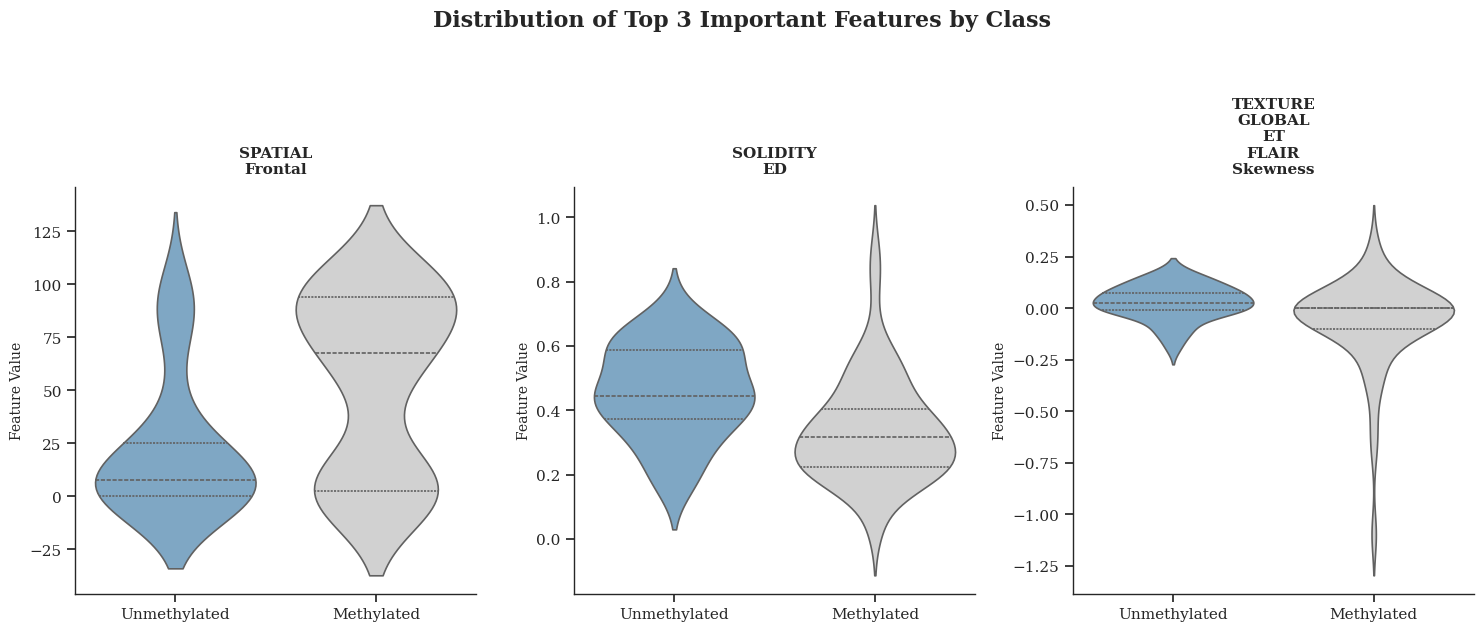

[INFO] Saved the updated Top 3 violin plots to: rf_xgboost_20\Figure_Top3_ViolinPlots_Separate.png


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
# Calculate the mean absolute SHAP value for each feature
shap_importance = np.abs(vals_to_plot).mean(axis=0)

# Sort and get the indices of the top 3 features
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

print(f"[INFO] Top 3 Features: {list(top3_features)}")

# ---------------------------------------------------------
# 2. Prepare data for plotting
# ---------------------------------------------------------
# Extract only the top 3 features
df_top3 = Xtr_ga[top3_features].copy()

# Add class labels mapping (0: Unmethylated, 1: Methylated)
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. Create Independent Subplots for each feature
# ---------------------------------------------------------
# Create a 1x3 grid of subplots to allow independent Y-axes
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Custom palette consistent with previous plots
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}

for i, feature in enumerate(top3_features):
    # Plot violin plot for each feature on its own axis
    sns.violinplot(
        data=df_top3, 
        x='Class',           # X-axis represents the two classes
        y=feature,           # Y-axis is the specific feature's value
        ax=axes[i],
        palette=my_palette,
        inner="quart",       # Show quartiles inside the violin
        linewidth=1.2,
        hue='Class',         # <--- 추가: x축과 동일하게 hue를 지정합니다.
        legend=False,
        order=['Unmethylated', 'Methylated'] # Maintain consistent order
    )
    
    # Set the title to the feature name (wrap text if it's too long)
    # Replace underscores with spaces for better readability in the title
    display_title = feature.replace('_', '\n') 
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=10)
    
    # Clean up axis labels
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    
    # Remove top and right borders for a cleaner look
    sns.despine(ax=axes[i])

# Add a main title for the entire figure
plt.suptitle("Distribution of Top 3 Important Features by Class", 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()

# Save the figure
save_path_violin = os.path.join(save_folder, "Figure_Top3_ViolinPlots_Separate.png")
plt.savefig(save_path_violin, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the updated Top 3 violin plots to: {save_path_violin}")

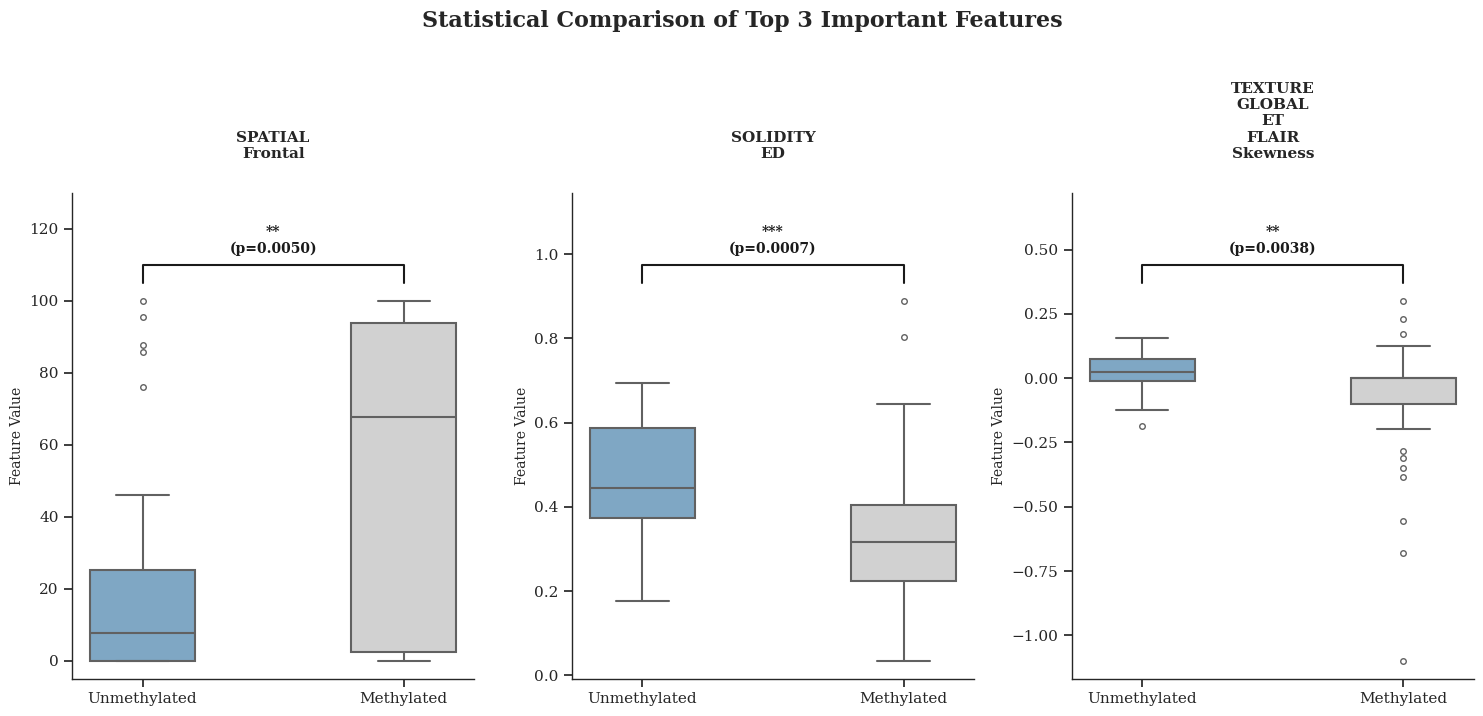

[INFO] Saved the Box Plots with p-values to: rf_xgboost_20\Figure_Top3_BoxPlots_with_Pvalue.png


In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
shap_importance = np.abs(vals_to_plot).mean(axis=0)
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

# ---------------------------------------------------------
# 2. Prepare data
# ---------------------------------------------------------
df_top3 = Xtr_ga[top3_features].copy()
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. Visualization with Statistical Testing (Mann-Whitney U)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}
order = ['Unmethylated', 'Methylated']

for i, feature in enumerate(top3_features):
    # Create Box Plot
    sns.boxplot(
        data=df_top3, x='Class', y=feature, hue='Class', legend=False,
        ax=axes[i], palette=my_palette, width=0.4, fliersize=4,
        linewidth=1.5, order=order
    )
    
    # Optional: Add individual points to show the actual distribution/outliers
    # sns.stripplot(
    #     data=df_top3, x='Class', y=feature, ax=axes[i], 
    #     color='black', size=3, alpha=0.3, jitter=True, order=order
    # )

    # --- Statistical Test (Mann-Whitney U) ---
    group1 = df_top3[df_top3['Class'] == 'Unmethylated'][feature]
    group2 = df_top3[df_top3['Class'] == 'Methylated'][feature]
    stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')

    # Determine significance level (Stars)
    if p_val < 0.001: sig = "***"
    elif p_val < 0.01: sig = "**"
    elif p_val < 0.05: sig = "*"
    else: sig = "n.s."

    # Annotation logic: Place the p-value at the top of the plot
    y_max = df_top3[feature].max()
    y_min = df_top3[feature].min()
    h = (y_max - y_min) * 0.05  # Height for the annotation line
    
    # Drawing the bracket and text
    axes[i].plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.5, c='k')
    axes[i].text(0.5, y_max + 2.5*h, f"{sig}\n(p={p_val:.4f})", 
                 ha='center', va='bottom', color='k', fontsize=10, fontweight='bold')

    # Styling
    display_title = feature.replace('_', '\n')
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=25)
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylim(y_min - h, y_max + 6*h) # Adjust limit to fit annotation
    sns.despine(ax=axes[i])

plt.suptitle("Statistical Comparison of Top 3 Important Features", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save
save_path_stat = os.path.join(save_folder, "Figure_Top3_BoxPlots_with_Pvalue.png")
plt.savefig(save_path_stat, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the Box Plots with p-values to: {save_path_stat}")

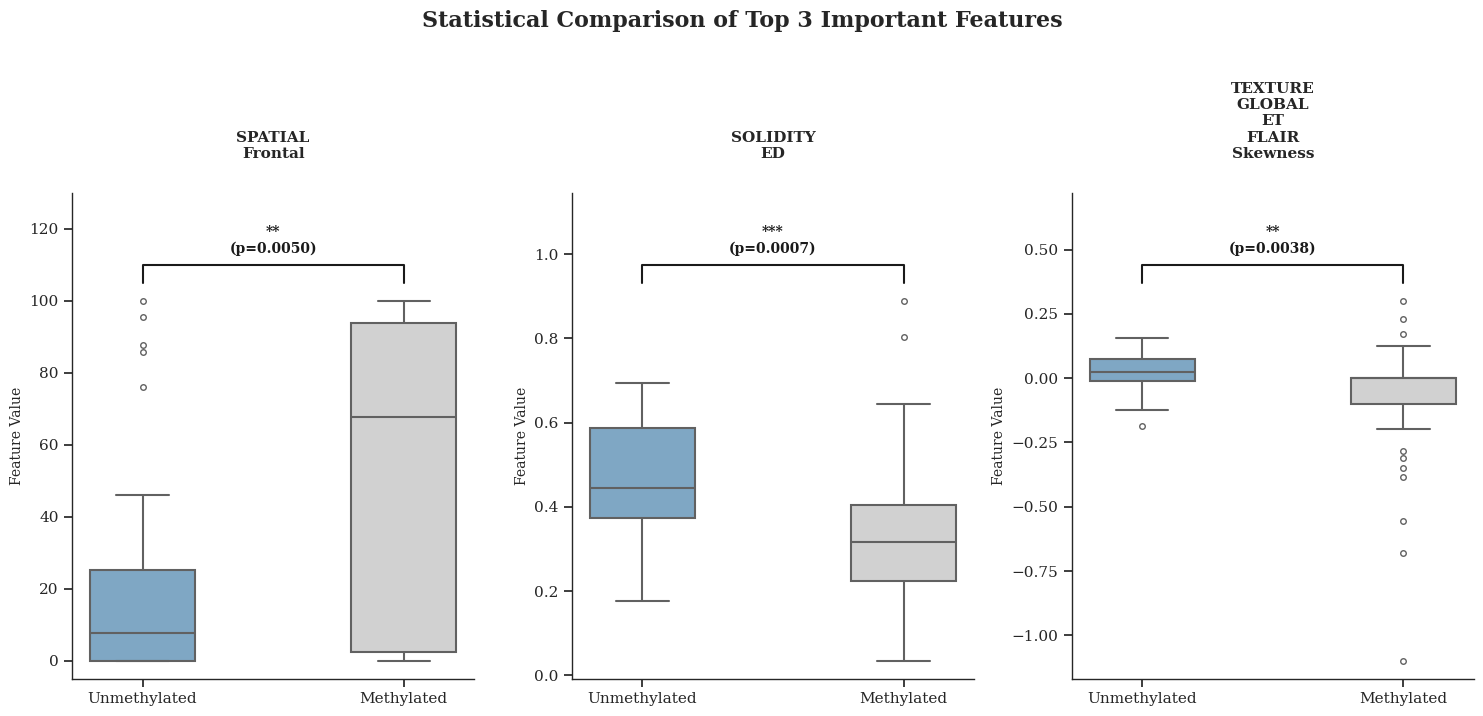

[INFO] Saved the Box Plots with p-values to: rf_xgboost_20\Figure_Top3_BoxPlots_with_Pvalue.png


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
shap_importance = np.abs(vals_to_plot).mean(axis=0)
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

# ---------------------------------------------------------
# 2. Prepare data
# ---------------------------------------------------------
df_top3 = Xtr_ga[top3_features].copy()
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. Visualization with Statistical Testing (Mann-Whitney U)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}
order = ['Unmethylated', 'Methylated']

for i, feature in enumerate(top3_features):
    # Create Box Plot
    sns.boxplot(
        data=df_top3, x='Class', y=feature, hue='Class', legend=False,
        ax=axes[i], palette=my_palette, width=0.4, fliersize=4,
        linewidth=1.5, order=order
    )
    
    # Optional: Add individual points to show the actual distribution/outliers
    # sns.stripplot(
    #     data=df_top3, x='Class', y=feature, ax=axes[i], 
    #     color='black', size=3, alpha=0.3, jitter=True, order=order
    # )

    # --- Statistical Test (Mann-Whitney U) ---
    group1 = df_top3[df_top3['Class'] == 'Unmethylated'][feature]
    group2 = df_top3[df_top3['Class'] == 'Methylated'][feature]
    stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')

    # Determine significance level (Stars)
    if p_val < 0.001: sig = "***"
    elif p_val < 0.01: sig = "**"
    elif p_val < 0.05: sig = "*"
    else: sig = "n.s."

    # Annotation logic: Place the p-value at the top of the plot
    y_max = df_top3[feature].max()
    y_min = df_top3[feature].min()
    h = (y_max - y_min) * 0.05  # Height for the annotation line
    
    # Drawing the bracket and text
    axes[i].plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.5, c='k')
    axes[i].text(0.5, y_max + 2.5*h, f"{sig}\n(p={p_val:.4f})", 
                 ha='center', va='bottom', color='k', fontsize=10, fontweight='bold')

    # Styling
    display_title = feature.replace('_', '\n')
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=25)
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylim(y_min - h, y_max + 6*h) # Adjust limit to fit annotation
    sns.despine(ax=axes[i])

plt.suptitle("Statistical Comparison of Top 3 Important Features", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save
save_path_stat = os.path.join(save_folder, "Figure_Top3_BoxPlots_with_Pvalue.png")
plt.savefig(save_path_stat, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the Box Plots with p-values to: {save_path_stat}")

[INFO] Majority-vote features: >= 3/5 GA subsets
[INFO] n_features = 10
[CV] GA-majority (k>=3/5) best AUC = 0.8436
[CV] GA-majority (k>=3/5) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 603}

===== TRAIN (5-fold CV, fixed tuned params) =====
Best CV AUC from tuning (rs.best_score_) : 0.8436
CV AUC (mean ± std)                     : 0.8242 ± 0.0843
CV Sensitivity@0.5 (mean ± std)         : 0.8509 ± 0.1055


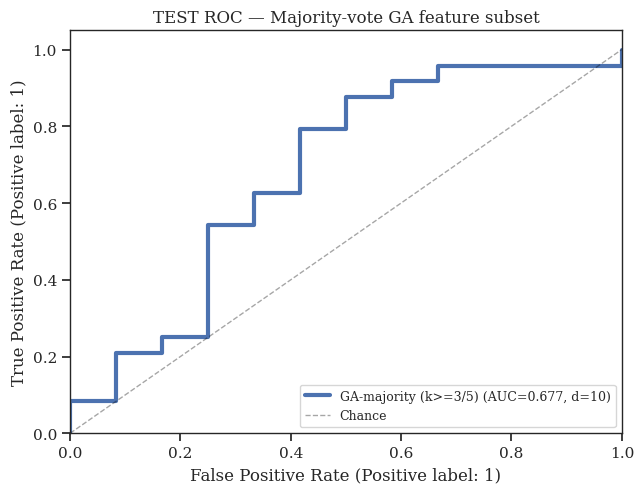


===== SUMMARY: Majority-vote GA subset (CV & TEST) =====
n_features  : 10
TEST AUC    : 0.6771


In [33]:
# Cell: Majority-vote (>=3 of 5 GA subsets) -> tune RF -> train(CV) AUC/sensitivity -> test ROC

# -----------------------------
# 0) Majority-vote feature subset from GA top-5 (>=3/5)
# -----------------------------
ga5 = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga5) < 5:
    raise ValueError(f"Need 5 GA subsets in feature_sets. Found {len(ga5)}.")
ga5 = ga5[:5]

n_feat_total = X_train.shape[1]
cnt = np.zeros(n_feat_total, dtype=int)
for fs in ga5:
    cols = np.asarray(fs["cols"], dtype=int)
    cnt[cols] += 1

MAJ_K = 3
maj_cols = np.where(cnt >= MAJ_K)[0]
if len(maj_cols) == 0:
    raise ValueError(f"No features appear in >= {MAJ_K} of the 5 GA subsets.")

print(f"[INFO] Majority-vote features: >= {MAJ_K}/5 GA subsets")
print(f"[INFO] n_features = {len(maj_cols)}")

# -----------------------------
# 1) Tune RF on TRAIN using your existing tuning function
# -----------------------------
maj_label = f"GA-majority (k>={MAJ_K}/5)"
maj_best_params, maj_cv_best = tune_rf_for_features(maj_cols, maj_label)

# -----------------------------
# 2) Train metrics via 5-fold CV (fixed best_params): AUC + sensitivity@0.5
# -----------------------------
Xtr = X_train.iloc[:, maj_cols].to_numpy()
ytr = y_np

auc_folds  = []
sens_folds = []

for tr_idx, va_idx in cv5.split(Xtr, ytr):
    X_tr, X_va = Xtr[tr_idx], Xtr[va_idx]
    y_tr, y_va = ytr[tr_idx], ytr[va_idx]

    clf = RandomForestClassifier(
        random_state=2026,
        n_jobs=-1,
        **maj_best_params
    )
    clf.fit(X_tr, y_tr)

    prob_va = clf.predict_proba(X_va)[:, 1]
    auc_va  = roc_auc_score(y_va, prob_va)

    pred_va = (prob_va >= 0.5).astype(int)
    pos = (y_va == 1)
    sens_va = ((pred_va == 1) & pos).sum() / max(pos.sum(), 1)

    auc_folds.append(auc_va)
    sens_folds.append(sens_va)

cv_auc_mean  = float(np.mean(auc_folds))
cv_auc_std   = float(np.std(auc_folds, ddof=1)) if len(auc_folds) > 1 else 0.0
cv_sens_mean = float(np.mean(sens_folds))
cv_sens_std  = float(np.std(sens_folds, ddof=1)) if len(sens_folds) > 1 else 0.0

print("\n===== TRAIN (5-fold CV, fixed tuned params) =====")
print(f"Best CV AUC from tuning (rs.best_score_) : {maj_cv_best:.4f}")
print(f"CV AUC (mean ± std)                     : {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
print(f"CV Sensitivity@0.5 (mean ± std)         : {cv_sens_mean:.4f} ± {cv_sens_std:.4f}")

# -----------------------------
# 3) Fit on FULL TRAIN, evaluate on TEST, plot TEST ROC
# -----------------------------
Xte = X_test.iloc[:, maj_cols].to_numpy()

final_clf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
final_clf.fit(Xtr, ytr)

prob_te = final_clf.predict_proba(Xte)[:, 1]
test_auc = float(roc_auc_score(y_te, prob_te))
fpr, tpr, _ = roc_curve(y_te, prob_te)

plt.figure(figsize=(6.6, 5.1))
plt.plot(
    fpr, tpr,
    lw=3.0,
    label=f"{maj_label} (AUC={test_auc:.3f}, d={len(maj_cols)})"
)
plt.plot([0, 1], [0, 1], "--", lw=1, color="black", alpha=0.35, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Majority-vote GA feature subset")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print("\n===== SUMMARY: Majority-vote GA subset (CV & TEST) =====")
print(f"n_features  : {len(maj_cols)}")
print(f"TEST AUC    : {test_auc:.4f}")


[CV] GA-majority (k>=3/5) best AUC = 0.8436
[CV] GA-majority (k>=3/5) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_samples': 1.0, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 603}


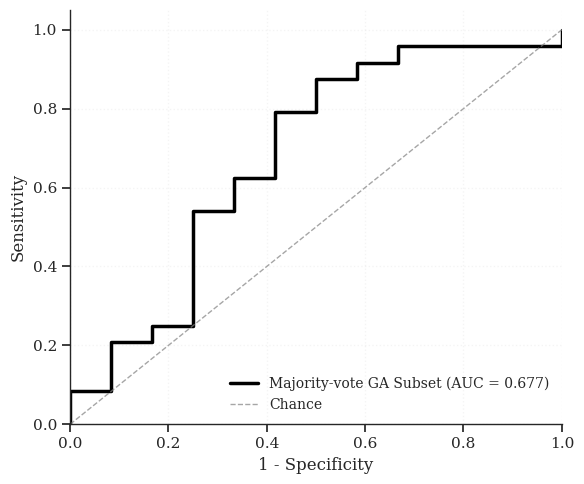

[INFO] 다수결 모델 결과가 저장되었습니다: MajorityVote\Figure_ROC_MajorityVote.png
Selected features (d=10): [ 0  1  5 25 34 35 45 63 66 77]


In [34]:
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------
save_folder = "MajorityVote"
os.makedirs(save_folder, exist_ok=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 0) Majority-vote feature subset 추출 (>= 3/5)
# ---------------------------------------------------------
ga5 = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga5) < 5:
    raise ValueError(f"Need 5 GA subsets. Found {len(ga5)}.")
ga5 = ga5[:5]

n_feat_total = X_train.shape[1]
cnt = np.zeros(n_feat_total, dtype=int)
for fs in ga5:
    cols = np.asarray(fs["cols"], dtype=int)
    cnt[cols] += 1

MAJ_K = 3
maj_cols = np.where(cnt >= MAJ_K)[0]

# 1) Tune RF (기존 함수 활용)
maj_label = f"GA-majority (k>={MAJ_K}/5)"
maj_best_params, maj_cv_best = tune_rf_for_features(maj_cols, maj_label)

# ---------------------------------------------------------
# 2. 모델 학습 및 테스트 데이터 평가
# ---------------------------------------------------------
Xtr = X_train.iloc[:, maj_cols].to_numpy()
ytr = y_np
Xte = X_test.iloc[:, maj_cols].to_numpy()
yte = y_te

final_clf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
final_clf.fit(Xtr, ytr)

prob_te = final_clf.predict_proba(Xte)[:, 1]
test_auc = float(roc_auc_score(yte, prob_te))
fpr, tpr, _ = roc_curve(yte, prob_te)

# ---------------------------------------------------------
# 3. 논문용 클린 ROC 플롯 생성
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))

# 메인 ROC 곡선 (검정색 굵은 선으로 강조)
plt.plot(
    fpr, tpr, 
    lw=2.5, 
    color="black", 
    label=f"Majority-vote GA Subset (AUC = {test_auc:.3f})"
)

# Chance line (점선)
plt.plot([0, 1], [0, 1], color='gray', lw=1.0, ls='--', alpha=0.7, label="Chance")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# 논문 규격 축 이름
plt.xlabel("1 - Specificity", fontsize=12)
plt.ylabel("Sensitivity", fontsize=12)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(alpha=0.2, ls=':')
sns.despine()

plt.tight_layout()

# ---------------------------------------------------------
# 4. 저장 (MajorityVote 폴더)
# ---------------------------------------------------------
save_path = os.path.join(save_folder, "Figure_ROC_MajorityVote.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] 다수결 모델 결과가 저장되었습니다: {save_path}")
print(f"Selected features (d={len(maj_cols)}): {maj_cols}")

[INFO] Final Majority-vote RF model for SHAP trained. Features: 10


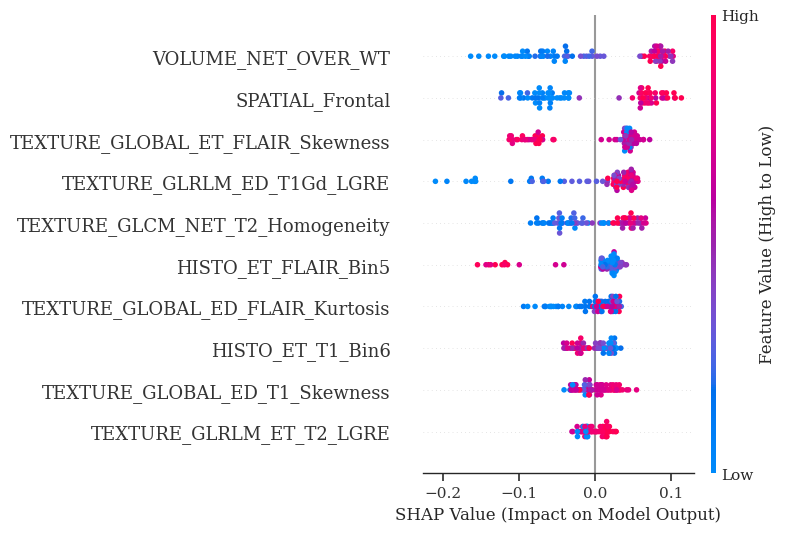

[INFO] SHAP Summary Plot이 저장되었습니다: MajorityVote\Figure_SHAP_MajorityVote.png


In [35]:
import os
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------
save_folder = "MajorityVote"
os.makedirs(save_folder, exist_ok=True)

# 논문용 폰트 설정
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 2. 모델 학습 (Majority-vote Subset)
# ---------------------------------------------------------
# 앞서 선택된 maj_cols와 maj_best_params 사용
Xtr_maj = X_train.iloc[:, maj_cols]
y_tr    = y_train.to_numpy().ravel()

rf_maj_shap = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
rf_maj_shap.fit(Xtr_maj, y_tr)

print(f"[INFO] Final Majority-vote RF model for SHAP trained. Features: {Xtr_maj.shape[1]}")

# ---------------------------------------------------------
# 3. SHAP 계산 (TreeExplainer)
# ---------------------------------------------------------
explainer = shap.TreeExplainer(rf_maj_shap)
shap_values = explainer.shap_values(Xtr_maj)

# 이진 분류 데이터 구조 처리
# scikit-learn RF 결과가 리스트인 경우 Positive(1) 클래스 선택
if isinstance(shap_values, list):
    vals_to_plot = shap_values[1]
else:
    vals_to_plot = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

# ---------------------------------------------------------
# 4. 시각화 및 고해상도 저장
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))



# SHAP Summary Plot 생성 (불필요한 제목 제거)
shap.summary_plot(
    vals_to_plot, 
    Xtr_maj, 
    feature_names=Xtr_maj.columns,
    max_display=15,
    plot_type="dot", 
    show=False
)

# 축 라벨 정돈
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.gcf().axes[-1].set_ylabel("Feature Value (High to Low)", fontsize=12)

# 여백 조정 및 파일 저장
plt.tight_layout()
save_path = os.path.join(save_folder, "Figure_SHAP_MajorityVote.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] SHAP Summary Plot이 저장되었습니다: {save_path}")

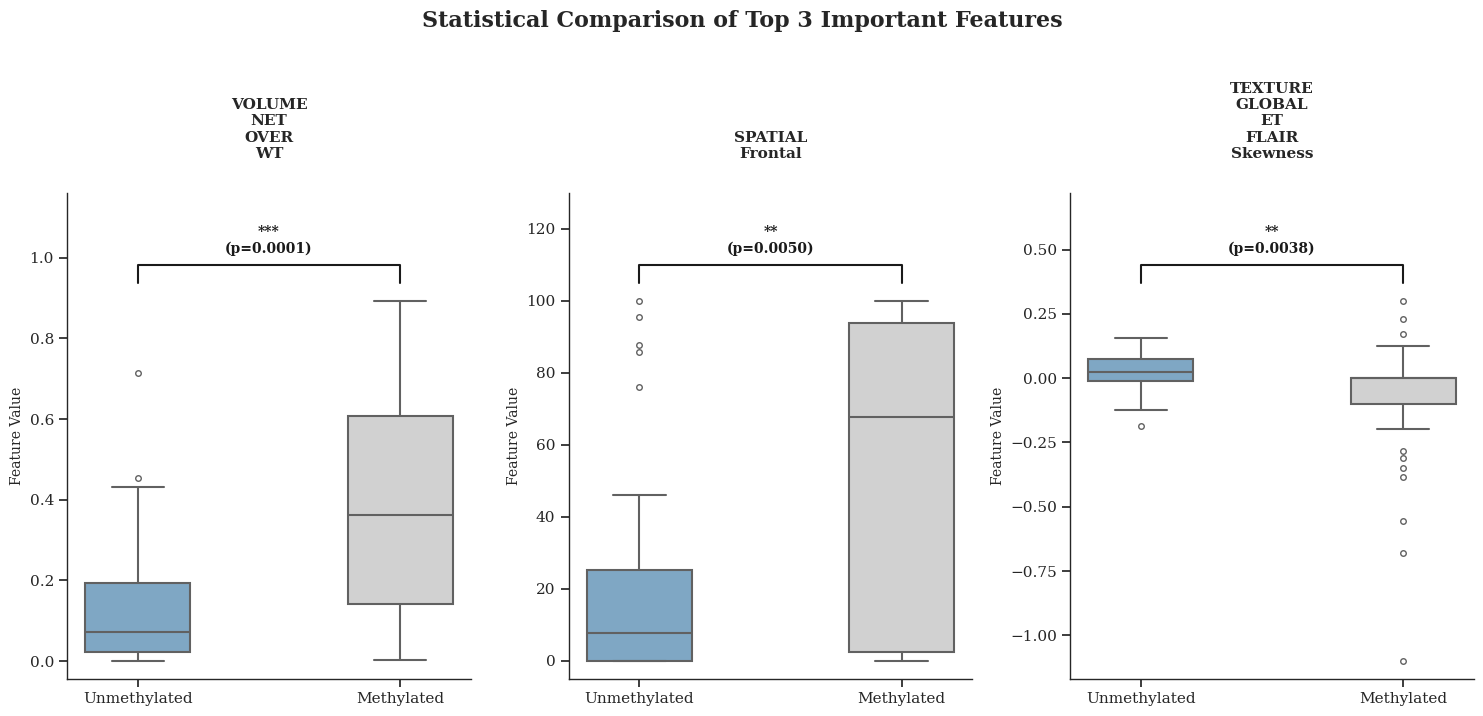

[INFO] 사용자님 스타일의 Box Plot이 저장되었습니다: MajorityVote\Figure_Top3_BoxPlots_MajorityVote.png


In [37]:
# ---------------------------------------------------------
# 1. SHAP 기반 Top 3 피처 추출 (AttributeError 방지형)
# ---------------------------------------------------------
shap_importance = np.abs(vals_to_plot).mean(axis=0)
top3_indices = np.argsort(shap_importance)[::-1][:3]

# [수정] Xtr_ga 대신 현재 사용 중인 Xtr_maj와 원본 컬럼명 사용
all_maj_feature_names = X_train.columns[maj_cols] 
top3_features = all_maj_feature_names[top3_indices]

# ---------------------------------------------------------
# 2. 데이터 준비 (Numpy 대응)
# ---------------------------------------------------------
# [수정] Xtr_maj를 안전하게 DataFrame으로 변환 후 추출
df_top3 = pd.DataFrame(Xtr_maj, columns=all_maj_feature_names)[top3_features].copy()
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. 시각화 (사용자님의 15x7 사이즈 및 스타일 그대로)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 7)) # 사용자님 원본 사이즈
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}
order = ['Unmethylated', 'Methylated']

for i, feature in enumerate(top3_features):
    # Box Plot (사용자님 설정: fliersize=4, linewidth=1.5)
    sns.boxplot(
        data=df_top3, x='Class', y=feature, hue='Class', legend=False,
        ax=axes[i], palette=my_palette, width=0.4, fliersize=4,
        linewidth=1.5, order=order
    )
    
    # --- Statistical Test (Mann-Whitney U) ---
    group1 = df_top3[df_top3['Class'] == 'Unmethylated'][feature]
    group2 = df_top3[df_top3['Class'] == 'Methylated'][feature]
    stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')

    # 유의성 별표 처리
    if p_val < 0.001: sig = "***"
    elif p_val < 0.01: sig = "**"
    elif p_val < 0.05: sig = "*"
    else: sig = "n.s."

    # Annotation logic (사용자님 원본 수치: 2*h, 2.5*h)
    y_max = df_top3[feature].max()
    y_min = df_top3[feature].min()
    h = (y_max - y_min) * 0.05
    
    # 브라켓과 텍스트
    axes[i].plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.5, c='k')
    axes[i].text(0.5, y_max + 2.5*h, f"{sig}\n(p={p_val:.4f})", 
                 ha='center', va='bottom', color='k', fontsize=10, fontweight='bold')

    # 스타일링 (사용자님 원본 설정)
    display_title = feature.replace('_', '\n')
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=25)
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylim(y_min - h, y_max + 6*h) 
    sns.despine(ax=axes[i])

plt.suptitle("Statistical Comparison of Top 3 Important Features", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# 저장
save_path_stat = os.path.join(save_folder, "Figure_Top3_BoxPlots_MajorityVote.png")
plt.savefig(save_path_stat, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] 사용자님 스타일의 Box Plot이 저장되었습니다: {save_path_stat}")